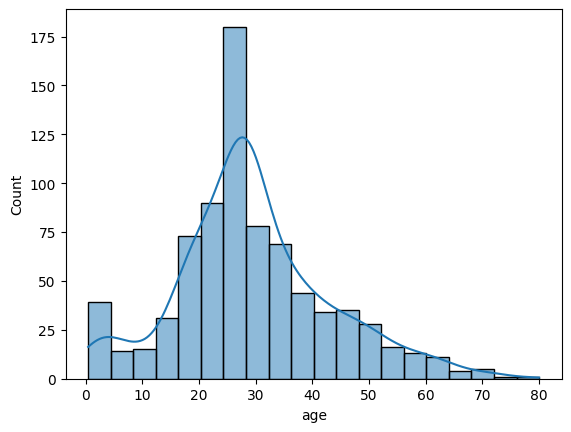

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Confusion Matrix:
[[89  0]
 [ 0 68]]


In [ ]:
# Week 4
# Experiment: Data Science Workflow and Processing Pipeline
# Program: Titanic Survival Prediction

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

# Data Collection
df = sns.load_dataset("titanic")

# Data Cleaning
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df.drop_duplicates(inplace=True)

# Encoding
df = pd.get_dummies(
    df,
    columns=['sex', 'class', 'embarked'],
    drop_first=True
)

# Feature Engineering
df['family_size'] = df['sibsp'] + df['parch']

# EDA
sns.histplot(df['age'], bins=20, kde=True)
plt.show()

# Modeling
df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))